
# Limpieza de datos
<small> 
 Análisis inicial:

 - Valores nulos
 - Duplicados
 - Formatos inconsistentes (fechas, decimales, texto)
 - Claves foráneas sin correspondencia
 - Corrección de categorías mal asignadas en productos

 ## Objetivo
 Preparar los archivos .xlsx para análisis, asegurando consistencia, completitud y validez de claves.

 ## Archivos tratados
 - Clientes.xlsx
 - Productos.xlsx
 - Ventas.xlsx
 - Detalle_ventas.xlsx
</small>

In [311]:
import pandas as pd

In [312]:
# Carga de datos
df_clientes = pd.read_excel(r".\Base de datos\Clientes.xlsx")
df_productos = pd.read_excel(r".\Base de datos\Productos.xlsx")
df_ventas = pd.read_excel(r".\Base de datos\\Ventas.xlsx")
df_detalle_ventas = pd.read_excel(r".\Base de datos\Detalle_ventas.xlsx")

In [313]:
#Verificar si hay valores nulos clientes
df_clientes.isnull().sum()

id_cliente        0
nombre_cliente    0
email             0
ciudad            0
fecha_alta        0
dtype: int64

In [314]:
#Verificar si hay valores nulos productos
df_productos.isnull().sum()

id_producto        0
nombre_producto    0
categoria          0
precio_unitario    0
dtype: int64

In [315]:
#Verificar si hay valores nulos ventas
df_ventas.isnull().sum()

id_venta          0
fecha             0
id_cliente        0
nombre_cliente    0
email             0
medio_pago        0
dtype: int64

In [316]:
#Verificar si hay valores nulos detalles_ventas
df_detalle_ventas.isnull().sum()

id_venta           0
id_producto        0
nombre_producto    0
cantidad           0
precio_unitario    0
importe            0
dtype: int64

In [317]:
# Convertir fechas desde formato Excel solo si las columnas no están ya en datetime
# Si vienen como números (serial Excel) los convertimos; si vienen como strings usamos to_datetime.
if not pd.api.types.is_datetime64_any_dtype(df_clientes["fecha_alta"]):
	if pd.api.types.is_numeric_dtype(df_clientes["fecha_alta"]):
		# serial Excel -> datetime
		df_clientes["fecha_alta"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df_clientes["fecha_alta"], unit="D")
	else:
		# intentar parsear strings a datetime
		df_clientes["fecha_alta"] = pd.to_datetime(df_clientes["fecha_alta"], errors="coerce")

if not pd.api.types.is_datetime64_any_dtype(df_ventas["fecha"]):
	if pd.api.types.is_numeric_dtype(df_ventas["fecha"]):
		df_ventas["fecha"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df_ventas["fecha"], unit="D")
	else:
		df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"], errors="coerce")

In [318]:
#Verificar tipo de datos
df_clientes.info()
df_productos.info()
df_ventas.info()
df_detalle_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_cliente      100 non-null    int64         
 1   nombre_cliente  100 non-null    object        
 2   email           100 non-null    object        
 3   ciudad          100 non-null    object        
 4   fecha_alta      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_producto      100 non-null    int64 
 1   nombre_producto  100 non-null    object
 2   categoria        100 non-null    object
 3   precio_unitario  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB
<class 'pandas.core.frame.DataFrame'>
Ran

In [319]:
#Convertir precio, cantidad e importe de int a float
df_productos["precio_unitario"] = df_productos["precio_unitario"].astype(float)
df_detalle_ventas["precio_unitario"] = df_detalle_ventas["precio_unitario"].astype(float)
df_detalle_ventas["cantidad"] = df_detalle_ventas["cantidad"].astype(float)
df_detalle_ventas["importe"] = df_detalle_ventas["importe"].astype(float)

print(df_detalle_ventas[["precio_unitario", "cantidad", "importe"]].dtypes)
print(df_productos["precio_unitario"].dtype)

# Si vienen como texto con coma decimal
df_detalle_ventas["precio_unitario"] = (
    df_detalle_ventas["precio_unitario"]
    .astype(str)
    .str.replace(".", "", regex=False)  # elimina separador de miles
    .str.replace(",", ".", regex=False)  # convierte coma decimal a punto
)
df_detalle_ventas["precio_unitario"] = pd.to_numeric(df_detalle_ventas["precio_unitario"], errors="coerce")

# Si están en entero
df_detalle_ventas["precio_unitario"] = df_detalle_ventas["precio_unitario"].astype(float)
df_detalle_ventas["cantidad"] = df_detalle_ventas["cantidad"].astype(float)

df_productos["precio_unitario"] = (
    df_productos["precio_unitario"]
    .astype(str)
    .str.replace(".", "", regex=False)  # elimina separador de miles
    .str.replace(",", ".", regex=False)  # convierte coma decimal a punto
)
df_productos["precio_unitario"] = pd.to_numeric(df_productos["precio_unitario"], errors="coerce")

precio_unitario    float64
cantidad           float64
importe            float64
dtype: object
float64


In [320]:
#Comprobar si existen filas duplicadas y eliminarlas si las hubiera
df_clientes.duplicated().sum()
df_productos.duplicated().sum()
df_ventas.duplicated().sum()
df_detalle_ventas.duplicated().sum()

np.int64(0)

In [321]:
# Validar claves foráneas
clientes_ids = set(df_clientes["id_cliente"])
ventas_ids = set(df_ventas["id_cliente"])
missing_clientes = ventas_ids - clientes_ids
print("Clientes faltantes en tabla clientes:", missing_clientes)
print("Cantidad de clientes faltantes:", len(missing_clientes))

productos_ids = set(df_productos["id_producto"])
detalle_ids = set(df_detalle_ventas["id_producto"])
missing_productos = detalle_ids - productos_ids
print("Productos faltantes en tabla productos:", missing_productos)
print("Cantidad de productos faltantes:", len(missing_productos))

ventas_ids = set(df_ventas["id_venta"])
detalle_ids = set(df_detalle_ventas["id_venta"])
missing_ventas = detalle_ids - ventas_ids
print("Ventas en detalle_ventas que no existen en ventas:", missing_ventas)
print("Cantidad de ventas faltantes:", len(missing_ventas))

Clientes faltantes en tabla clientes: set()
Cantidad de clientes faltantes: 0
Productos faltantes en tabla productos: set()
Cantidad de productos faltantes: 0
Ventas en detalle_ventas que no existen en ventas: set()
Cantidad de ventas faltantes: 0


In [322]:
import unicodedata

# Palabras clave
palabras_alimentos = [
    "coca","pepsi","sprite","fanta","agua","jugo","yerba","te","leche","yogur","queso",
    "manteca","pan","medialuna","bizcocho","galletita","alfajor","papas","mani","chocolate",
    "turron","barrita","dulce","mermelada","helado","aceite","vinagre","salsa","arroz",
    "fideos","lentejas","garbanzos","porotos","harina","azucar","sal","cerveza","vino",
    "whisky","ron","vodka","gin","licor","pizza","empanadas","verduras","hamburguesas",
    "aceitunas","miel","stevia","granola","avena","sopa","caldo","caramelo","chicle",
    "chupetin","energetica","cafe","sidra","fernet"
]

palabras_limpieza = [
    "detergente","lavandina","jabon","shampoo","papel higienico","toallas humedas",
    "desodorante","crema dental","cepillo","dientes","hilo dental","mascarilla","suavizante",
    "limpiavidrios","desengrasante","esponja","trapo"
]

# Normalización
def normalize_text(s):
    s = str(s).lower()
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    return s

# Corrección de categoría
def corregir_categoria(nombre, categoria_original):
    nombre_n = normalize_text(nombre)
    # Primero limpieza (prioridad)
    if any(p in nombre_n for p in palabras_limpieza):
        return "Limpieza"
    # Luego alimentos
    if any(p in nombre_n for p in palabras_alimentos):
        return "Alimentos"
    # Si no hay coincidencia, conservar
    return categoria_original

# Aplicar corrección
df_productos["categoria"] = df_productos.apply(
    lambda row: corregir_categoria(row["nombre_producto"], row["categoria"]), axis=1
)


In [323]:
clientes_copy = df_clientes
productos_copy = df_productos
ventas_copy = df_ventas
detalle_ventas_copy = df_detalle_ventas

# Exportar cada DataFrame limpio
clientes_copy.to_csv("clientes_limpio.csv", index=False)
productos_copy.to_csv("productos_limpio.csv", index=False)
ventas_copy.to_csv("ventas_limpio.csv", index=False)
detalle_ventas_copy.to_csv("detalle_ventas_limpio.csv", index=False)

# Estadistica descriptiva El análisis genera las siguientes métricas estadísticas:

Descriptivas: Promedios, mínimos, máximos y totales de venta.

Agrupaciones de Negocio:

Categorías más vendidas.

Medios de pago más usados.

Ventas totales mes a mes.

Calidad del Dato: Detecta si el promedio de ventas está distorsionado por valores extremos (comparando Media vs. Mediana).

Correlaciones: Analiza qué variables (como precio y cantidad) están relacionadas matemáticamente.

### 3. Uniendo DataFrames para el análisis... ###
¡Datos unidos! Este es el DataFrame maestro para el análisis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id_venta                  343 non-null    int64         
 1   fecha                     343 non-null    datetime64[ns]
 2   id_cliente                343 non-null    int64         
 3   nombre_cliente_x          343 non-null    object        
 4   email_x                   343 non-null    object        
 5   medio_pago                343 non-null    object        
 6   id_producto               343 non-null    int64         
 7   nombre_producto_venta     343 non-null    object        
 8   cantidad                  343 non-null    float64       
 9   precio_unitario_venta     343 non-null    float64       
 10  importe                   343 non-

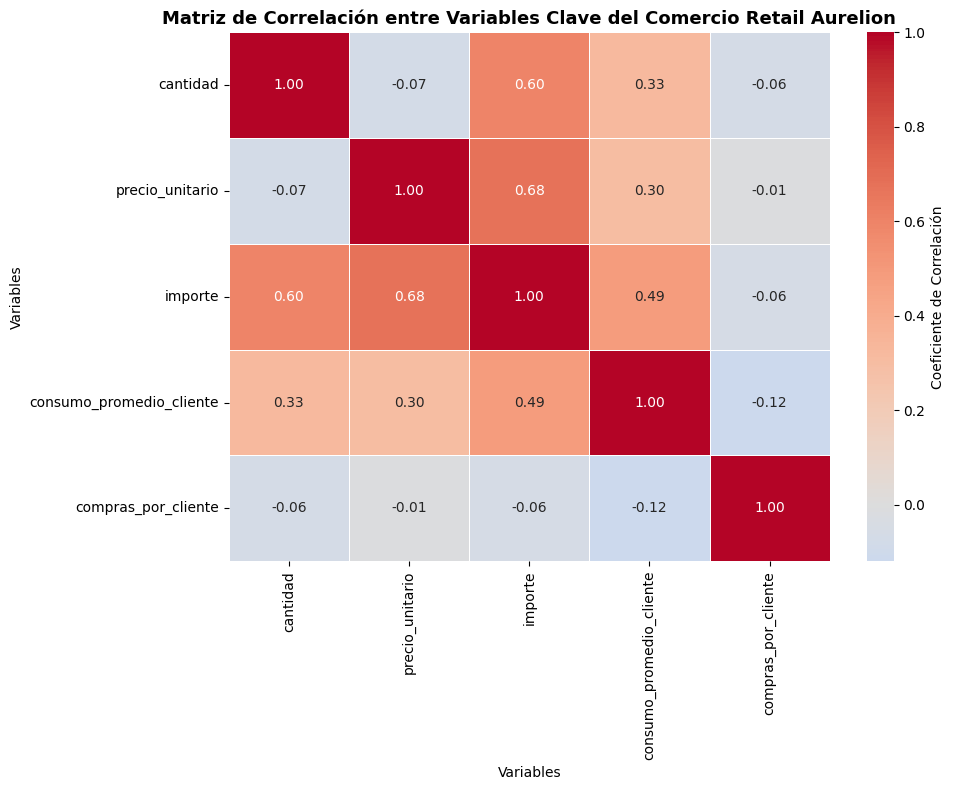

Matriz de correlación exportada correctamente a 'matriz_correlacion_retail_aurelion.xlsx'.


In [324]:
# ---
# 3. UNIR DATAFRAMES
# ---
print("### 3. Uniendo DataFrames para el análisis... ###")
# Unimos ventas con sus detalles
df_ventas_detalle = pd.merge(df_ventas, df_detalle_ventas, on="id_venta")
# Añadimos la información de los productos
df_completo = pd.merge(df_ventas_detalle, df_productos, on="id_producto", suffixes=('_venta', '_producto'))
# Añadimos la información de los clientes
# Usamos df_clientes (no clientes_copy)
df_completo = pd.merge(df_completo, df_clientes, on="id_cliente")

# Convertimos la 'fecha' (que vino de df_ventas) a datetime por si acaso
df_completo['fecha'] = pd.to_datetime(df_completo['fecha'])

print("¡Datos unidos! Este es el DataFrame maestro para el análisis:")
print(df_completo.info())
print("\n" + "="*50 + "\n")

# 4. CÁLCULO DE ESTADÍSTICAS BÁSICAS (Paso 2 del PDF)
print("### 4. Estadísticas Descriptivas (Función .describe()) ###")
columnas_numericas = ['cantidad', 'precio_unitario_producto', 'importe']
print(df_completo[columnas_numericas].describe())
print("\n" + "="*50 + "\n")

# 5. INTERPRETACIÓN DE NEGOCIO
print("### 5. Análisis de Negocio (Función .groupby() y .agg()) ###")

# 5.1. Total de Ventas (Importe Total)
total_ventas = df_completo['importe'].sum()
print(f"Ingresos Totales: ${total_ventas:,.2f}\n")

# 5.2. Ventas por Categoría de Producto
ventas_por_categoria = df_completo.groupby('categoria')['importe'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)
print("--- Ventas por Categoría ---")
print(ventas_por_categoria)
print("\n")

# 5.3. Medios de Pago más usados (Frecuencias)
print("--- Medios de Pago más usados ---")

print(df_completo['medio_pago'].value_counts(normalize=True) * 100)
print("\n")

# 5.4. Ticket Promedio (Promedio de 'importe' por 'id_venta')
total_por_venta = df_completo.groupby('id_venta')['importe'].sum()
ticket_promedio = total_por_venta.mean()
print(f"Ticket Promedio por Venta: ${ticket_promedio:,.2f}\n")

# 5.5. Ventas a lo largo del tiempo (Agrupado por Mes)
df_temporal = df_completo.set_index('fecha')
# Agrupamos por fin de mes ('ME') y sumamos el importe
ventas_por_mes = df_temporal['importe'].resample('ME').sum()
# -------------------------
print("--- Ventas Totales por Mes ---")
print(ventas_por_mes)
print("\n" + "="*50 + "\n")


# ---
# 6. IDENTIFICAR DISTRIBUCIÓN Y OUTLIERS
# ---
print("### 6. Análisis de Distribución (Media vs. Mediana) ###")
media_importe = df_completo['importe'].mean()
mediana_importe = df_completo['importe'].median()
print(f"Media del 'importe': ${media_importe:,.2f}")
print(f"Mediana del 'importe': ${mediana_importe:,.2f}")

# (Lógica de interpretación)
if media_importe > mediana_importe * 1.1:
    print("\nInterpretación: La Media es significativamente MÁS ALTA que la Mediana.")
    print("Esto indica una **distribución sesgada a la derecha**.")
    print("Causa: Existen algunas ventas con un 'importe' muy alto (outliers) que 'inflan' el promedio.")
    print("Conclusión: Para este caso, la **Mediana** es una medida más confiable del 'importe' típico.")
elif mediana_importe > media_importe * 1.1:
    print("\nInterpretación: La Mediana es significativamente MÁS ALTA que la Media.")
    print("Esto indica una **distribución sesgada a la izquierda**.")
    print("Causa: Existen algunas ventas con un 'importe' muy bajo que 'arrastran' el promedio hacia abajo.")
else:
    print("\nInterpretación: La Media y la Mediana son muy similares.")
    print("Esto indica una **distribución normal** o simétrica.")
print("\n" + "="*50 + "\n")

# ---
# 7. ANÁLISIS DE CORRELACIÓN PEARSON CON MATRIZ
# ---

import seaborn as sns
import matplotlib.pyplot as plt

print("### 7. Análisis de Correlación Pearson ###")

# Verificamos nombre real del precio unitario (tras el merge)
if "precio_unitario_producto" in df_completo.columns:
    df_completo["precio_unitario"] = df_completo["precio_unitario_producto"]
elif "precio_unitario" not in df_completo.columns:
    raise KeyError("No se encontró ninguna columna de precio_unitario en df_completo.")

# Crear consumo promedio por cliente
df_completo["consumo_promedio_cliente"] = df_completo.groupby("id_cliente")["importe"].transform("mean")

# Crear número total de compras por cliente
df_completo["compras_por_cliente"] = df_completo.groupby("id_cliente")["id_venta"].transform("count")


# Variables clave del negocio
# Se incluyen variables de venta, producto y comportamiento del cliente
variables_correlacion = [
    "cantidad",
    "precio_unitario",
    "importe",
    "consumo_promedio_cliente",
    "compras_por_cliente"
]

# Filtrar las columnas relevantes y eliminar valores nulos
df_corr = df_completo[variables_correlacion].dropna()

# Matriz de correlación (Pearson)
matriz_correlacion = df_corr.corr(method='pearson')

# Mostrar matriz en consola
print("\n--- Matriz de Correlación (Pearson) ---\n")
print(matriz_correlacion)
print("\n")

# --- Visualización de la Matriz de Correlación ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm',#mapa de colores
    center=0,
    fmt=".2f", #números con dos decimales.
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación'} #barra lateral de colores
)
plt.title("Matriz de Correlación entre Variables Clave del Comercio Retail Aurelion", fontsize=13, weight='bold')
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# --- Exportar la matriz de correlación ---
matriz_correlacion.to_excel("matriz_correlacion_retail_aurelion.xlsx")

print("Matriz de correlación exportada correctamente a 'matriz_correlacion_retail_aurelion.xlsx'.")



# Interpretación de los resultados respecto al analisis de correlación:

a) cantidad vs importe → 0.60 (correlación positiva moderada)

Cuantas más unidades se venden, mayor es el importe total de la venta. Esto confirma la relación esperada entre volumen y valor económico.
Sin embargo, no es una correlación perfecta (no es cercana a 1), lo que sugiere que existen otros factores —como el precio o descuentos— que también influyen en el importe final.

Implicancia: El negocio puede incrementar sus ingresos tanto aumentando las unidades vendidas como ajustando precios estratégicamente.
Los productos con más demanda (alta cantidad) no siempre generan los ingresos más altos.

b) precio_unitario vs importe → 0.68 (correlación positiva moderada-alta)

A mayor precio, mayor importe total por venta. Esto indica que el precio influye significativamente en los ingresos, incluso más que la cantidad.
Puede deberse a que los productos más caros tienen un mayor peso en la facturación.

Implicancia: El negocio debería identificar los productos de alto valor unitario porque son los que más aportan a las ventas.
Esto ayuda a definir una estrategia de “productos estrella” en las campañas o promociones.

c) precio_unitario vs cantidad → –0.07 (correlación ligeramente negativa)

La relación es muy débilmente inversa: cuando el precio sube, la cantidad tiende a bajar ligeramente.
Esto puede indicar una leve sensibilidad del consumidor al precio (elasticidad de la demanda), pero no es una relación fuerte.

Implicancia: El cliente promedio no reacciona fuertemente a cambios de precio. Esto da margen para estrategias de ajuste de precios sin un gran impacto en la cantidad vendida (útil para maximizar rentabilidad).

d) consumo_promedio_cliente vs importe → 0.49 (correlación positiva moderada)

Los clientes que suelen tener un consumo promedio alto (tickets grandes) también generan ventas de mayor importe.
Refleja la importancia del segmento de clientes de alto gasto.

Implicancia: Es conveniente segmentar y fidelizar a estos clientes con estrategias de retención, descuentos personalizados o programas de lealtad, ya que son los que aportan más a las ventas totales.

e) compras_por_cliente vs consumo_promedio_cliente → –0.12 (correlación negativa débil)

Los clientes que compran más veces tienden a tener un ticket promedio ligeramente menor.
Esto suele ser común en retail: clientes frecuentes hacen compras pequeñas pero constantes, mientras que otros realizan pocas compras de alto valor.

Implicancia: El negocio podría diferenciar sus estrategias de marketing: Promociones “cross-selling” o combos para los clientes frecuentes.
Promociones “premium” para los de alto gasto promedio pero baja frecuencia.

f) compras_por_cliente vs importe → –0.06 (sin relación significativa)

La frecuencia de compra no se relaciona directamente con el monto de cada venta. Esto indica que hay segmentos de clientes con comportamientos distintos (por ejemplo, algunos compran poco pero caro, otros mucho pero barato).

Implicancia: Refuerza la necesidad de segmentar la base de clientes y analizar sus patrones de compra individuales.

### 8.1. Visualización de Outliers con Boxplot para 'importe' ###


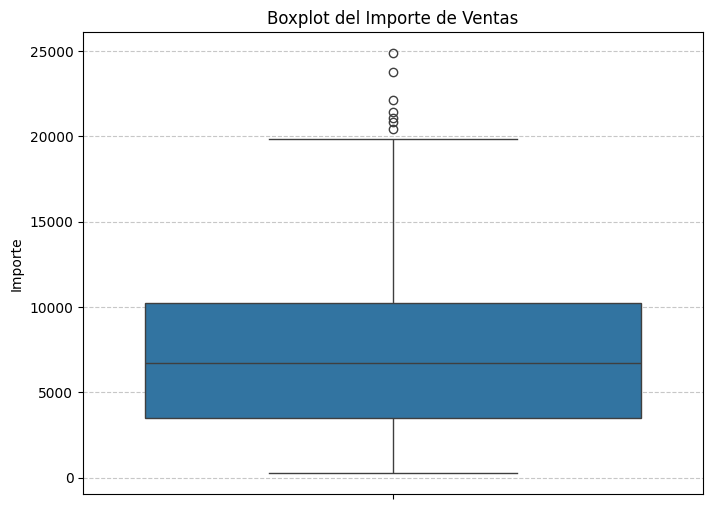


--- Interpretación del Boxplot ---
Los puntos individuales fuera de los 'bigotes' del boxplot representan los posibles outliers. Estos son valores que se desvían significativamente de la mayoría de las ventas.


### 8.2. Detección de Outliers usando el Método IQR para 'importe' ###
Q1 (Primer Cuartil): 3,489.00
Q3 (Tercer Cuartil): 10,231.50
IQR (Rango Intercuartílico): 6,742.50
Límite Inferior para Outliers: -6,624.75
Límite Superior para Outliers: 20,345.25

Número de Outliers detectados: 7
Detalles de los Outliers (primeras 10 filas si hay muchos):
     id_venta      fecha  id_cliente    nombre_cliente_x                      email_x     medio_pago  id_producto       nombre_producto_venta  cantidad  precio_unitario_venta  importe    nombre_producto_producto  categoria  precio_unitario_producto    nombre_cliente_y                      email_y       ciudad fecha_alta  precio_unitario  consumo_promedio_cliente  compras_por_cliente
41         16 2024-04-12           2       Nicolas Roja

In [325]:
# --- 8. Detección y Visualización de Outliers en la columna 'importe' ---
# La detección de outliers es crucial para entender si hay valores extremos que podrían distorsionar el análisis.
# Utilizaremos dos métodos:
# 1. Visualización con Boxplots: Permite identificar gráficamente los valores que se encuentran fuera de los 'bigotes'
#    del diagrama de caja, que son los candidatos a outliers.
# 2. Método del Rango Intercuartílico (IQR): Una técnica estadística para definir un rango aceptable de datos
#    y marcar como outliers aquellos valores que caen por debajo del límite inferior o por encima del límite superior.
#    Los límites se calculan como:
#    * Límite Inferior = Q1 - 1.5 * IQR
#    * Límite Superior = Q3 + 1.5 * IQR
#    Donde Q1 es el primer cuartil (25%), Q3 es el tercer cuartil (75%) e IQR = Q3 - Q1.

print("### 8.1. Visualización de Outliers con Boxplot para 'importe' ###")

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_completo['importe'])
plt.title('Boxplot del Importe de Ventas')
plt.ylabel('Importe')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n--- Interpretación del Boxplot ---")
print("Los puntos individuales fuera de los 'bigotes' del boxplot representan los posibles outliers. Estos son valores que se desvían significativamente de la mayoría de las ventas.")
print("\n" + "="*50 + "\n")

print("### 8.2. Detección de Outliers usando el Método IQR para 'importe' ###")

Q1 = df_completo['importe'].quantile(0.25)
Q3 = df_completo['importe'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1 (Primer Cuartil): {Q1:,.2f}")
print(f"Q3 (Tercer Cuartil): {Q3:,.2f}")
print(f"IQR (Rango Intercuartílico): {IQR:,.2f}")
print(f"Límite Inferior para Outliers: {limite_inferior:,.2f}")
print(f"Límite Superior para Outliers: {limite_superior:,.2f}")

# Identificar los outliers
outliers = df_completo[(df_completo['importe'] < limite_inferior) | (df_completo['importe'] > limite_superior)]

print(f"\nNúmero de Outliers detectados: {len(outliers)}")
print("Detalles de los Outliers (primeras 10 filas si hay muchos):")
print(outliers.head(10).to_string())

print("\n--- Interpretación de Outliers IQR ---")
print("Los registros mostrados son considerados outliers según el método IQR. Pueden representar transacciones excepcionalmente grandes o pequeñas que podrían requerir una investigación adicional o un tratamiento especial en el análisis. La decisión de eliminarlos o no dependerá del contexto del negocio y del objetivo del análisis.")
print("\n" + "="*50 + "\n")

# **Nuestro Análisis de Outliers: Clave para la Tienda**

Como equipo, **decidimos usar el Rango Intercuartílico (IQR)** para detectar ventas inusualmente grandes o pequeñas (outliers). Elegimos el IQR porque se enfoca en el 50% central de nuestras ventas, dándonos una base sólida para definir lo 'normal' y evitar que promedios se distorsionen por ventas extremas.

**Resultados Clave:**

*   **Q1 (25% inferior): $3,489.00**
*   **Q3 (75% inferior): $10,231.50**
*   **IQR: $6,742.50** (la dispersión del 50% central)
*   **Límites para Outliers:** Por debajo de $-6,624.75$ o por encima de $20,345.25$.

**Identificamos 7 ventas como outliers**, todas ellas significativamente mayores que nuestras transacciones habituales. No encontramos outliers de ventas inusualmente pequeñas.

**¿Por qué es esto relevante para nuestra tienda de barrio?**

Estos 7 outliers de alto valor son cruciales para nosotros:

1.  **Clientes de Alto Valor:** Probablemente corresponden a clientes importantes. **Nos permite** diseñar estrategias de fidelización específicas para ellos, como descuentos por volumen o servicios personalizados.
2.  **Productos con Potencial:** Nos ayuda a identificar qué productos se venden en grandes cantidades. **Nos señala** nuestros 'productos estrella' para optimizar inventario y ofertas.
3.  **Estrategias de Venta:** **Nos indica** qué medios de pago son populares para grandes transacciones y si nuestras promociones fomentan compras mayores.
4.  **Potencial de Crecimiento:** Estos outliers **nos muestran** el techo de lo que podemos lograr por transacción, **impulsándonos** a replicar esas condiciones y explorar nuevos segmentos de mercado.

En resumen, el análisis de outliers con el método IQR **nos permite** entender fenómenos atípicos pero significativos para la rentabilidad y el crecimiento de nuestra tienda, y **nos guía** en los próximos pasos.

Top ciudades por importe total de compras:
ciudad
Rio Cuarto     792203.0
Alta Gracia    481504.0
Cordoba        481482.0
Carlos Paz     353852.0
Villa Maria    313350.0
Name: importe, dtype: float64
Top clientes por importe total:
id_cliente
5     132158.0
56     90701.0
52     90522.0
25     81830.0
1      72448.0
Name: importe, dtype: float64
Top productos por cantidad vendida:
                            cantidad  importe
nombre_producto_producto                     
Salsa de Tomate 500g            27.0  23949.0
Queso Rallado 150g              26.0  89544.0
Hamburguesas Congeladas x4      24.0  58080.0
Vino Blanco 750ml               22.0  59048.0
Aceitunas Verdes 200g           22.0  55440.0
Tiempo promedio de conversión (días): 387.03
LTV promedio por ciudad:
ciudad
Rio Cuarto     44011.277778
Cordoba        43771.090909
Carlos Paz     39316.888889
Villa Maria    39168.750000
Alta Gracia    34393.142857
dtype: float64


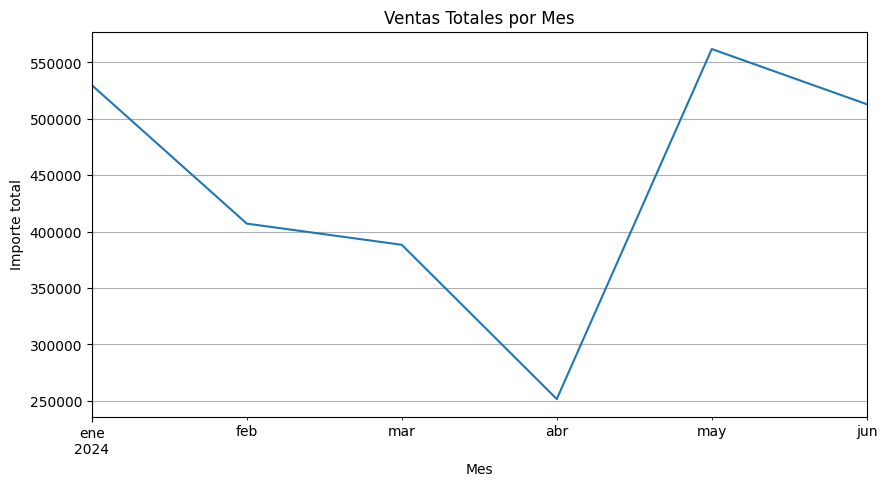

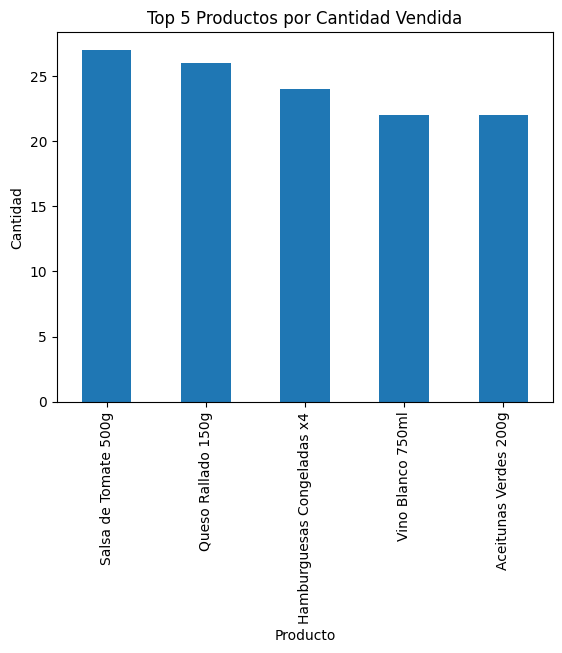

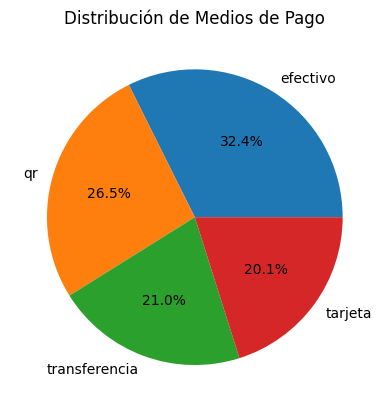

In [326]:

# Ciudad con más compras
compras_por_ciudad = df_completo.groupby("ciudad")["importe"].sum().sort_values(ascending=False)
print("Top ciudades por importe total de compras:")
print(compras_por_ciudad.head(5))

#  Top clientes por importe total
top_clientes = df_completo.groupby("id_cliente")["importe"].sum().sort_values(ascending=False)
print("Top clientes por importe total:")
print(top_clientes.head(5))

# Producto más vendido (por cantidad y por importe)
# Tras el merge el nombre del producto puede haberse renombrado; elegimos la columna disponible
if "nombre_producto_producto" in df_completo.columns:
	product_name_col = "nombre_producto_producto"
elif "nombre_producto_venta" in df_completo.columns:
	product_name_col = "nombre_producto_venta"
elif "nombre_producto" in df_completo.columns:
	product_name_col = "nombre_producto"
else:
	# Como fallback agrupar por id_producto si no existe columna de nombre
	product_name_col = "id_producto"

productos_mas_vendidos = df_completo.groupby(product_name_col)[["cantidad", "importe"]].sum().sort_values(by="cantidad", ascending=False)
print("Top productos por cantidad vendida:")
print(productos_mas_vendidos.head(5))

# Tiempo de conversión (alta → primera compra)
primeras_compras = df_completo.groupby("id_cliente")["fecha"].min()
conversion = (primeras_compras - df_clientes.set_index("id_cliente")["fecha_alta"]).dt.days
conversion_promedio = conversion.mean()
print(f"Tiempo promedio de conversión (días): {conversion_promedio:.2f}")

# LTV por ciudad (Lifetime Value promedio)
ltv_por_ciudad = df_completo.groupby("ciudad")["importe"].sum() / df_completo.groupby("ciudad")["id_cliente"].nunique()
print("LTV promedio por ciudad:")
print(ltv_por_ciudad.sort_values(ascending=False).head(5))

# Visualizaciones automatizadas

# Ventas por mes
ventas_por_mes = df_completo.resample("ME", on="fecha")["importe"].sum()
ventas_por_mes.plot(kind="line", title="Ventas Totales por Mes", figsize=(10,5))
plt.ylabel("Importe total")
plt.xlabel("Mes")
plt.grid(True)
plt.show()

# Top productos
productos_mas_vendidos["cantidad"].head(5).plot(kind="bar", title="Top 5 Productos por Cantidad Vendida")
plt.ylabel("Cantidad")
plt.xlabel("Producto")
plt.show()

# Medios de pago
df_completo["medio_pago"].value_counts().plot(kind="pie", autopct="%1.1f%%", title="Distribución de Medios de Pago")
plt.ylabel("")
plt.show()

